<a href="https://colab.research.google.com/github/HaneinOmar/Find_Jobs/blob/main/ICDM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Text



In [ ]:
import os
import pandas as pd
import nltk
from textblob import TextBlob
from transformers import BertTokenizer, BertModel
import torch

nltk.download("punkt")
nltk.download("punkt_tab")

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
bert_model = BertModel.from_pretrained("bert-base-uncased")


def extract_text_features(text):

    features = {}

    tokens = nltk.word_tokenize(text)
    sentences = nltk.sent_tokenize(text)

    # Linguistic features
    features["word_count"] = len(tokens)
    features["sentence_count"] = len(sentences)
    features["avg_sentence_length"] = len(tokens) / (len(sentences)+1)
    features["ttr"] = len(set(tokens)) / (len(tokens)+1)

    # Sentiment
    blob = TextBlob(text)
    features["polarity"] = blob.sentiment.polarity
    features["subjectivity"] = blob.sentiment.subjectivity

    # BERT embedding (first 20 dims فقط)
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=256)
    outputs = bert_model(**inputs)
    emb = outputs.last_hidden_state.mean(dim=1).detach().numpy()[0]

    for i in range(20):
        features[f"bert_{i}"] = emb[i]

    return features

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
dep_path = "/content/drive/MyDrive/Colab Notebooks/MICCAI_Project/raw_data/depression/transcripts/"

dep_text_features = []

for file in os.listdir(dep_path):
    if file.endswith(".txt"):
        text = open(os.path.join(dep_path, file), encoding="utf-8").read()

        feats = extract_text_features(text)
        feats["id"] = file.replace(".txt","")

        dep_text_features.append(feats)

dep_text_df = pd.DataFrame(dep_text_features)
dep_text_df["label"] = "depression"

# حفظ الملف
dep_text_df.to_csv("depression_text_features.csv", index=False)

print("Depression features shape:", dep_text_df.shape)

Depression features shape: (178, 28)


In [ ]:
dem_path = "/content/drive/MyDrive/Colab Notebooks/MICCAI_Project/raw_data/dementia/generated_transcripts/dementia/"

dem_text_features = []

for file in os.listdir(dem_path):
    if file.endswith(".txt"):
        text = open(os.path.join(dem_path, file), encoding="utf-8").read()

        feats = extract_text_features(text)
        feats["id"] = file.replace(".txt","")

        dem_text_features.append(feats)

dem_text_df = pd.DataFrame(dem_text_features)
dem_text_df["label"] = "dementia"

dem_text_df.to_csv("dementia_text_features.csv", index=False)

print("Dementia features shape:", dem_text_df.shape)

Dementia features shape: (273, 28)


In [ ]:
from sklearn.ensemble import IsolationForest

dep_df = pd.read_csv("depression_text_features.csv")

X_dep = dep_df.drop(["id","label"], axis=1)

iso_model = IsolationForest(contamination=0.1, random_state=42)
iso_model.fit(X_dep)

# score للاكتئاب
dep_df["depression_score"] = iso_model.decision_function(X_dep)

print(dep_df[["id","depression_score"]].head())

    id  depression_score
0  310          0.068852
1  304          0.070756
2  311          0.048466
3  307         -0.002072
4  313          0.048003


In [ ]:
dem_df = pd.read_csv("dementia_text_features.csv")

X_dem = dem_df.drop(["id","label"], axis=1)

dem_df["depression_score"] = iso_model.decision_function(X_dem)

print(dem_df[["id","depression_score"]].head())

        id  depression_score
0    097-1         -0.170156
1    120-0         -0.142047
2  120-4_1         -0.104061
3  120-3_1         -0.098274
4    120-2         -0.084875


In [ ]:
threshold = dep_df["depression_score"].quantile(0.30)

dem_df["new_label"] = dem_df["depression_score"].apply(
    lambda x: "dementia_with_depression" if x < threshold else "dementia"
)

In [ ]:
dem_df.to_csv("dementia_classified.csv", index=False)

print("✅ New classified file saved!")

✅ New classified file saved!


In [ ]:
classified = pd.read_csv("dementia_classified.csv")

print("\n===== SAMPLE OUTPUT =====")
print(classified[["id","depression_score","new_label"]].head(10))

print("\n===== CLASS DISTRIBUTION =====")
print(classified["new_label"].value_counts())


===== SAMPLE OUTPUT =====
        id  depression_score                 new_label
0    097-1         -0.170156  dementia_with_depression
1    120-0         -0.142047  dementia_with_depression
2  120-4_1         -0.104061  dementia_with_depression
3  120-3_1         -0.098274  dementia_with_depression
4    120-2         -0.084875  dementia_with_depression
5    122-0         -0.126904  dementia_with_depression
6    122-1         -0.127121  dementia_with_depression
7    125-0         -0.149120  dementia_with_depression
8    127-0         -0.151822  dementia_with_depression
9    134-0         -0.088473  dementia_with_depression

===== CLASS DISTRIBUTION =====
new_label
dementia_with_depression    273
Name: count, dtype: int64


New Way

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
dep = pd.read_csv("depression_text_features.csv")
dem = pd.read_csv("dementia_text_features.csv")

X_dep = dep.drop(["id","label"], axis=1)
X_dem = dem.drop(["id","label"], axis=1)

FileNotFoundError: [Errno 2] No such file or directory: 'depression_text_features.csv'

In [ ]:
scaler = StandardScaler()

X_dep_scaled = scaler.fit_transform(X_dep)
X_dem_scaled = scaler.transform(X_dem)

In [ ]:
depression_centroid = np.mean(X_dep_scaled, axis=0)

In [ ]:
similarities = cosine_similarity(X_dem_scaled, depression_centroid.reshape(1,-1))

dem["depression_similarity"] = similarities.flatten()

In [ ]:
print(dem[["id","depression_similarity"]].head())

print("\nStats:")
print(dem["depression_similarity"].describe())

        id  depression_similarity
0    097-1          -6.506364e-16
1    120-0          -3.442794e-16
2  120-4_1          -4.472583e-16
3  120-3_1          -3.450432e-16
4    120-2          -3.434482e-16

Stats:
count    2.730000e+02
mean    -3.442585e-16
std      7.417311e-17
min     -8.850422e-16
25%     -3.511717e-16
50%     -3.241078e-16
75%     -3.019901e-16
max     -2.684288e-16
Name: depression_similarity, dtype: float64


In [ ]:
threshold = dem["depression_similarity"].quantile(0.70)

dem["new_label"] = dem["depression_similarity"].apply(
    lambda x: "dementia_with_depression" if x >= threshold else "dementia"
)

In [ ]:
print("\n===== FINAL OUTPUT =====")
print(dem[["id","depression_similarity","new_label"]].head(10))

print("\n===== CLASS DISTRIBUTION =====")
print(dem["new_label"].value_counts())


===== FINAL OUTPUT =====
        id  depression_similarity                 new_label
0    097-1          -6.506364e-16                  dementia
1    120-0          -3.442794e-16                  dementia
2  120-4_1          -4.472583e-16                  dementia
3  120-3_1          -3.450432e-16                  dementia
4    120-2          -3.434482e-16                  dementia
5    122-0          -3.469832e-16                  dementia
6    122-1          -3.104953e-16                  dementia
7    125-0          -2.684288e-16  dementia_with_depression
8    127-0          -3.666250e-16                  dementia
9    134-0          -3.330299e-16                  dementia

===== CLASS DISTRIBUTION =====
new_label
dementia                    191
dementia_with_depression     82
Name: count, dtype: int64


In [ ]:
output_path = "/content/dementia_final_classified.csv"

dem.to_csv(output_path, index=False)

print("Saved file to:", output_path)

Saved file to: /content/dementia_final_classified.csv


In [ ]:
check = pd.read_csv(output_path)
print(check.head())
print(check["new_label"].value_counts())

   word_count  sentence_count  avg_sentence_length       ttr  polarity  \
0          61               3            15.250000  0.596774  0.300000   
1         103              11             8.583333  0.490385  0.362500   
2         131               5            21.833333  0.560606  0.047222   
3         165              11            13.750000  0.530120 -0.012500   
4         105              10             9.545455  0.575472  0.221667   

   subjectivity    bert_0    bert_1    bert_2    bert_3  ...   bert_14  \
0      0.300000 -0.253116 -0.343432  0.356143 -0.218144  ... -0.038919   
1      0.350000 -0.284475  0.097923  0.363451  0.104794  ... -0.088046   
2      0.542593 -0.150865 -0.046043  0.247851 -0.049430  ... -0.169057   
3      0.455556 -0.079425  0.111258  0.282169 -0.074778  ... -0.094871   
4      0.378333 -0.154539 -0.094128  0.346044 -0.013156  ... -0.231972   

    bert_15   bert_16   bert_17   bert_18   bert_19       id     label  \
0  0.689748  0.293931 -0.049371 -0.1

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv(output_path)

X = df.drop(["id", "new_label", "depression_similarity", "label"], axis=1)
y = df["new_label"]

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
from sklearn.svm import SVC

model = SVC(kernel="rbf", probability=True)
model.fit(X_train, y_train)

SVC(probability=True)

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

y_pred = model.predict(X_test)

print("\n===== RESULTS =====")
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


===== RESULTS =====
Accuracy: 0.8181818181818182

Classification Report:

                          precision    recall  f1-score   support

                dementia       0.80      0.97      0.88        38
dementia_with_depression       0.89      0.47      0.62        17

                accuracy                           0.82        55
               macro avg       0.85      0.72      0.75        55
            weighted avg       0.83      0.82      0.80        55


Confusion Matrix:

[[37  1]
 [ 9  8]]


In [ ]:
# لازم probability=True في SVM (أنت فعلتها 👍)

y_prob = model.predict_proba(X_test)[:, 1]

In [ ]:
# dementia = 0
# dementia_with_depression = 1

y_test_binary = y_test.map({
    "dementia": 0,
    "dementia_with_depression": 1
})

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test_binary, y_prob)
roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)

AUC Score: 0.93343653250774


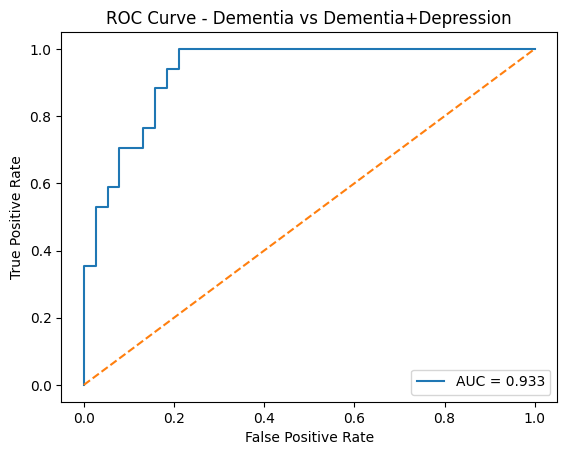

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")  # random line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Dementia vs Dementia+Depression")

plt.legend()
plt.show()

Aduio

In [ ]:
import librosa
import numpy as np
import pandas as pd
import os
from scipy.stats import skew, kurtosis

def extract_audio_features(file_path):
    y, sr = librosa.load(file_path, sr=None)

    features = {}

    features["centroid"] = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    features["rolloff"] = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
    features["rms"] = np.mean(librosa.feature.rms(y=y))
    features["zcr"] = np.mean(librosa.feature.zero_crossing_rate(y))

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    for i in range(13):
        features[f"mfcc_{i}"] = np.mean(mfcc[i])

    features["skew"] = skew(y)
    features["kurtosis"] = kurtosis(y)

    return features

In [ ]:
dep_audio_path = "/content/drive/MyDrive/Colab Notebooks/MICCAI_Project/raw_data/depression/audio/"

dep_audio_features = []

for file in os.listdir(dep_audio_path):
    if file.endswith(".wav"):
        feats = extract_audio_features(os.path.join(dep_audio_path, file))
        feats["id"] = file.replace(".wav","")
        dep_audio_features.append(feats)

dep_audio_df = pd.DataFrame(dep_audio_features)
dep_audio_df["label"] = "depression"

dep_audio_df.to_csv("depression_audio_features.csv", index=False)

print(dep_audio_df.shape)

/tmp/ipykernel_6242/1682154642.py:8: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=None)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


OSError: [Errno 107] Transport endpoint is not connected: '/content/drive/MyDrive/Colab Notebooks/MICCAI_Project/raw_data/depression/audio/300.wav'

In [ ]:
dem_audio_path = "/content/drive/MyDrive/Colab Notebooks/MICCAI_Project/raw_data/dementia/audio/"

dem_audio_features = []

for file in os.listdir(dem_audio_path):
    if file.endswith(".wav"):
        feats = extract_audio_features(os.path.join(dem_audio_path, file))
        feats["id"] = file.replace(".wav","")
        dem_audio_features.append(feats)

dem_audio_df = pd.DataFrame(dem_audio_features)
dem_audio_df["label"] = "dementia"

dem_audio_df.to_csv("dementia_audio_features.csv", index=False)

print(dem_audio_df.shape)

(273, 21)


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

dep = pd.read_csv("depression_audio_features.csv")
dem = pd.read_csv("dementia_audio_features.csv")

X_dep = dep.drop(["id","label"], axis=1)
X_dem = dem.drop(["id","label"], axis=1)

scaler = StandardScaler()

X_dep_scaled = scaler.fit_transform(X_dep)
X_dem_scaled = scaler.transform(X_dem)

# centroid
centroid = np.mean(X_dep_scaled, axis=0)

# similarity
similarity = cosine_similarity(X_dem_scaled, centroid.reshape(1,-1))

dem["depression_similarity"] = similarity.flatten()

In [ ]:
threshold = dem["depression_similarity"].quantile(0.70)

dem["new_label"] = dem["depression_similarity"].apply(
    lambda x: "dementia_with_depression" if x >= threshold else "dementia"
)

print(dem["new_label"].value_counts())

new_label
dementia                    191
dementia_with_depression     82
Name: count, dtype: int64


In [ ]:
dem.to_csv("dementia_audio_classified.csv", index=False)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

df = pd.read_csv("dementia_audio_classified.csv")

X = df.drop(["id","label","new_label","depression_similarity"], axis=1)
y = df["new_label"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

model = SVC(kernel="rbf", probability=True)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\n===== AUDIO RESULTS =====")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


===== AUDIO RESULTS =====
Accuracy: 0.8909090909090909
                          precision    recall  f1-score   support

                dementia       0.94      0.89      0.92        38
dementia_with_depression       0.79      0.88      0.83        17

                accuracy                           0.89        55
               macro avg       0.87      0.89      0.88        55
            weighted avg       0.90      0.89      0.89        55

[[34  4]
 [ 2 15]]


AUC: 0.9628482972136223


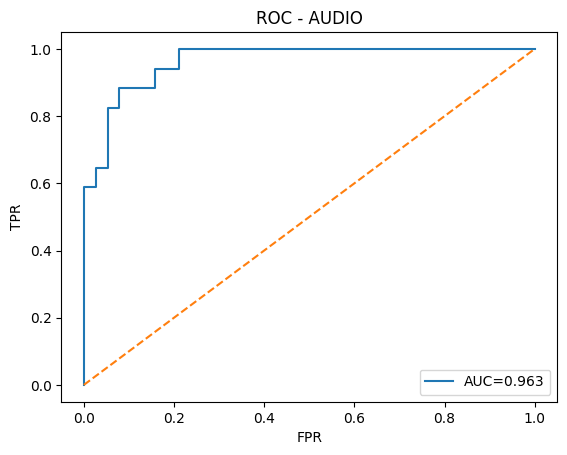

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test)[:,1]

y_test_bin = y_test.map({
    "dementia": 0,
    "dementia_with_depression": 1
})

fpr, tpr, thresholds = roc_curve(y_test_bin, y_prob)
roc_auc = auc(fpr, tpr)

print("AUC:", roc_auc)

plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC - AUDIO")
plt.legend()
plt.show()

Aduio and Text

In [ ]:
import pandas as pd

# TEXT
dep_text = pd.read_csv("depression_text_features.csv")
dem_text = pd.read_csv("dementia_text_features.csv")

# AUDIO
dep_audio = pd.read_csv("depression_audio_features.csv")
dem_audio = pd.read_csv("dementia_audio_features.csv")

In [ ]:
dep_text["id"] = dep_text["id"].astype(str)
dep_audio["id"] = dep_audio["id"].astype(str)

dem_text["id"] = dem_text["id"].astype(str)
dem_audio["id"] = dem_audio["id"].astype(str)

In [ ]:
dep = pd.merge(dep_text, dep_audio, on="id")
dem = pd.merge(dem_text, dem_audio, on="id")

In [ ]:
print(dep_text["id"].head())
print(dep_audio["id"].head())

0    310
1    304
2    311
3    307
4    313
Name: id, dtype: object
0    312_AUDIO
1          300
2          301
3          302
4          303
Name: id, dtype: object


In [ ]:
dep = pd.merge(dep_text, dep_audio, on="id")
dem = pd.merge(dem_text, dem_audio, on="id")

print("Dep shape:", dep.shape)
print("Dem shape:", dem.shape)

Dep shape: (176, 48)
Dem shape: (273, 48)


In [ ]:
X_dep = dep.drop(["id","label_x","label_y"], axis=1)
X_dem = dem.drop(["id","label_x","label_y"], axis=1)

In [ ]:
scaler = StandardScaler()

X_dep_scaled = scaler.fit_transform(X_dep)
X_dem_scaled = scaler.transform(X_dem)

In [ ]:
centroid = np.mean(X_dep_scaled, axis=0)

similarity = cosine_similarity(X_dem_scaled, centroid.reshape(1,-1))

dem["depression_similarity"] = similarity.flatten()

In [ ]:
threshold = dem["depression_similarity"].quantile(0.70)

dem["new_label"] = dem["depression_similarity"].apply(
    lambda x: "dementia_with_depression" if x >= threshold else "dementia"
)

print("\n===== CLASS DISTRIBUTION =====")
print(dem["new_label"].value_counts())


===== CLASS DISTRIBUTION =====
new_label
dementia                    191
dementia_with_depression     82
Name: count, dtype: int64


In [ ]:
output_path = "dementia_fusion_classified.csv"

dem.to_csv(output_path, index=False)

print("Saved to:", output_path)

Saved to: dementia_fusion_classified.csv


In [ ]:
output_path = "dementia_fusion_classified.csv"

dem.to_csv(output_path, index=False)

print("Saved to:", output_path)

Saved to: dementia_fusion_classified.csv


In [ ]:
df = pd.read_csv(output_path)

X = df.drop(["id","label_x","label_y","new_label","depression_similarity"], axis=1)
y = df["new_label"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

model = SVC(kernel="rbf", probability=True)
model.fit(X_train, y_train)

SVC(probability=True)

In [ ]:
y_pred = model.predict(X_test)

print("\n===== FUSION RESULTS =====")
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


===== FUSION RESULTS =====
Accuracy: 0.8414634146341463

Classification Report:

                          precision    recall  f1-score   support

                dementia       0.85      0.93      0.89        57
dementia_with_depression       0.80      0.64      0.71        25

                accuracy                           0.84        82
               macro avg       0.83      0.78      0.80        82
            weighted avg       0.84      0.84      0.84        82


Confusion Matrix:

[[53  4]
 [ 9 16]]



AUC Score: 0.9333333333333333


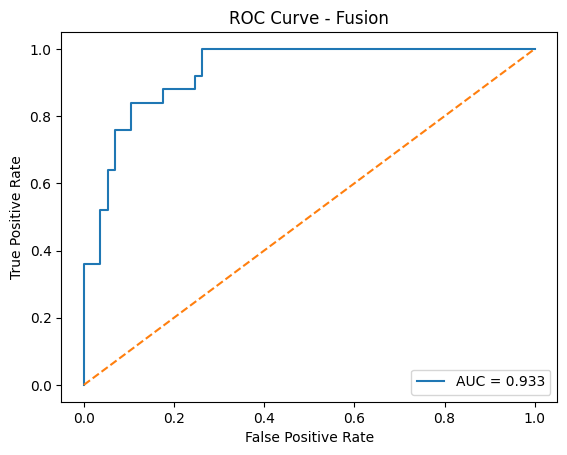

In [ ]:
y_prob = model.predict_proba(X_test)[:,1]

y_test_bin = y_test.map({
    "dementia": 0,
    "dementia_with_depression": 1
})

fpr, tpr, thresholds = roc_curve(y_test_bin, y_prob)
roc_auc = auc(fpr, tpr)

print("\nAUC Score:", roc_auc)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Fusion")

plt.legend()
plt.show()

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

mlp = MLPClassifier(
    hidden_layer_sizes=(128,64),
    max_iter=500,
    random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(mlp, X_scaled, y, cv=cv, scoring="accuracy")

print("\n===== MLP 5-FOLD CROSS VALIDATION =====")
print("Fold Accuracies:", scores)
print("Mean Accuracy:", scores.mean())
print("Std:", scores.std())


===== MLP 5-FOLD CROSS VALIDATION =====
Fold Accuracies: [0.83636364 0.89090909 0.81818182 0.88888889 0.88888889]
Mean Accuracy: 0.8646464646464647
Std: 0.03106122196974958


الطريقة السابقة مشكلتها انه فى حال التجارب الثلاثة انه يعرف عدد الاشخاص المصابين بالزهايمر والاكتئاب والزهايمر فقط نفس العدد وذلك لانه فى الطريقة نفسها تم تثبيت ان العدد الموجود 30% منها مصابين بالزهايمر والاكتئاب معا

New way


In [ ]:
!pip install praat-parselmouth

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 94.7 MB/s eta 0:00:00


In [ ]:
import librosa
import numpy as np
import parselmouth
from scipy.stats import skew, kurtosis

def extract_audio_features_advanced(file_path):

    y, sr = librosa.load(file_path, sr=None)

    features = {}

    # ===== Basic Features =====
    features["centroid"] = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    features["rolloff"] = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
    features["rms"] = np.mean(librosa.feature.rms(y=y))
    features["zcr"] = np.mean(librosa.feature.zero_crossing_rate(y))

    # ===== MFCC =====
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    for i in range(13):
        features[f"mfcc_{i}"] = np.mean(mfcc[i])

    # ===== Moments =====
    features["skew"] = skew(y)
    features["kurtosis"] = kurtosis(y)

    # =====================================================
    # 🔥 JITTER & SHIMMER (باستخدام Praat)
    # =====================================================

    try:
        snd = parselmouth.Sound(file_path)

        point_process = parselmouth.praat.call(
            snd, "To PointProcess (periodic, cc)", 75, 500
        )

        jitter = parselmouth.praat.call(
            point_process, "Get jitter (local)", 0, 0, 0.0001, 0.02, 1.3
        )

        shimmer = parselmouth.praat.call(
            [snd, point_process],
            "Get shimmer (local)",
            0, 0, 0.0001, 0.02, 1.3, 1.6
        )

        features["jitter"] = jitter
        features["shimmer"] = shimmer

    except:
        features["jitter"] = 0
        features["shimmer"] = 0

    return features

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# X و y من بيانات التدريب
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# Construct feature names
tfidf_feature_names = vectorizer.get_feature_names_out()
text_manual_feature_names = text_feature_cols
audio_feature_names = audio_feature_cols
all_feature_names = list(tfidf_feature_names) + list(text_manual_feature_names) + list(audio_feature_names)

importances = pd.Series(rf.feature_importances_, index=all_feature_names)

# أهم 20 feature
top_features = importances.sort_values(ascending=False).head(20)

print("\n===== TOP FEATURES =====")
print(top_features)

NameError: name 'X' is not defined

In [ ]:
selected_features = top_features.index.tolist()

X_selected = X[selected_features]

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, stratify=y, random_state=42
)

model = SVC(kernel="rbf", probability=True)
model.fit(X_train, y_train)

SVC(probability=True)

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = model.predict(X_test)

print("\n===== RESULTS AFTER FEATURE SELECTION =====")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


===== RESULTS AFTER FEATURE SELECTION =====
Accuracy: 0.8658536585365854
                          precision    recall  f1-score   support

                dementia       0.90      0.91      0.90        57
dementia_with_depression       0.79      0.76      0.78        25

                accuracy                           0.87        82
               macro avg       0.84      0.84      0.84        82
            weighted avg       0.86      0.87      0.87        82



In [ ]:
print("\n===== CLASS DISTRIBUTION =====")
print(y.value_counts(normalize=True))


===== CLASS DISTRIBUTION =====
new_label
dementia                    0.699634
dementia_with_depression    0.300366
Name: proportion, dtype: float64


In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

mlp = MLPClassifier(
    hidden_layer_sizes=(128,64),
    max_iter=500,
    random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(mlp, X_scaled, y, cv=cv, scoring="accuracy")

print("\n===== 5-FOLD CROSS VALIDATION =====")
print("Scores:", scores)
print("Mean Accuracy:", scores.mean())
print("Std:", scores.std())


===== 5-FOLD CROSS VALIDATION =====
Scores: [0.89090909 0.85454545 0.87272727 0.83333333 0.87037037]
Mean Accuracy: 0.8643771043771045
Std: 0.01933891370840648


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

model = SVC(kernel="rbf", probability=True)
model.fit(X_train, y_train)

train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc  = accuracy_score(y_test, model.predict(X_test))

print("\n===== OVERFITTING CHECK =====")
print("Train Accuracy:", train_acc)
print("Test Accuracy :", test_acc)


===== OVERFITTING CHECK =====
Train Accuracy: 0.9633507853403142
Test Accuracy : 0.8658536585365854


NEW WAY


**Text **

In [1]:
import os
import numpy as np
import pandas as pd
import shap
import nltk
from textblob import TextBlob
nltk.download('punkt')
nltk.download('punkt_tab')
import matplotlib.pyplot as plt


from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.mixture import GaussianMixture
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, recall_score
from sklearn.metrics import confusion_matrix, roc_curve, auc

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, recall_score

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [2]:
dementia_text_path = "/content/drive/MyDrive/Colab Notebooks/MICCAI_Project/raw_data/dementia/generated_transcripts/dementia/"
depression_text_path = "/content/drive/MyDrive/Colab Notebooks/MICCAI_Project/raw_data/depression/transcripts/"

In [3]:
def extract_manual_features(text):

    tokens = nltk.word_tokenize(text)
    sentences = nltk.sent_tokenize(text)

    word_count = len(tokens)
    sent_count = len(sentences)

    avg_len = word_count / (sent_count + 1)
    ttr = len(set(tokens)) / (word_count + 1)

    blob = TextBlob(text)

    return {
        "word_count": word_count,
        "sentence_count": sent_count,
        "avg_sentence_len": avg_len,
        "ttr": ttr,
        "sentiment": blob.sentiment.polarity
    }

In [4]:
def load_texts(path, label):

    texts = []
    features = []

    for f in os.listdir(path):
        if f.endswith(".txt"):

            text = open(os.path.join(path,f), encoding="utf-8").read()

            texts.append(text)

            feats = extract_manual_features(text)
            feats["id"] = f.replace(".txt","")
            feats["label"] = label

            features.append(feats)

    return texts, pd.DataFrame(features)

In [5]:
dep_texts, dep_df = load_texts(depression_text_path, "depression")
dem_texts, dem_df = load_texts(dementia_text_path, "dementia")

In [6]:
vectorizer = TfidfVectorizer(max_features=500)

X_dep_tfidf = vectorizer.fit_transform(dep_texts).toarray()
X_dem_tfidf = vectorizer.transform(dem_texts).toarray()

In [7]:
X_dep_manual = dep_df.drop(["id","label"], axis=1).values
X_dem_manual = dem_df.drop(["id","label"], axis=1).values

X_dep = np.hstack([X_dep_tfidf, X_dep_manual])
X_dem = np.hstack([X_dem_tfidf, X_dem_manual])

In [8]:
scaler = StandardScaler()

X_dep_s = scaler.fit_transform(X_dep)
X_dem_s = scaler.transform(X_dem)

# clustering على الزهايمر فقط
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_dem_s)

dem_df["cluster"] = clusters

In [9]:
# نحسب similarity لكل cluster مع بيانات الاكتئاب

from sklearn.metrics.pairwise import cosine_similarity

centroid_dep = X_dep_s.mean(axis=0)

cluster_scores = {}

for c in [0,1]:
    cluster_data = X_dem_s[clusters == c]
    sim = cosine_similarity(cluster_data, centroid_dep.reshape(1,-1))
    cluster_scores[c] = sim.mean()

# cluster الأعلى = depression-like
dep_cluster = max(cluster_scores, key=cluster_scores.get)

dem_df["new_label"] = dem_df["cluster"].apply(
    lambda x: "dementia_with_depression" if x==dep_cluster else "dementia"
)

In [10]:
dem_df.to_csv("text_realistic_clustered.csv", index=False)

In [11]:
print(dem_df[["id","new_label"]].head())

print("\nDistribution:")
print(dem_df["new_label"].value_counts())

        id new_label
0    097-1  dementia
1    120-0  dementia
2  120-4_1  dementia
3  120-3_1  dementia
4    120-2  dementia

Distribution:
new_label
dementia                    184
dementia_with_depression     89
Name: count, dtype: int64


In [12]:
X = X_dem
y = dem_df["new_label"]

X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

model = SVC(kernel="rbf", probability=True)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [13]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average="weighted"))
print("Recall:", recall_score(y_test, y_pred, average="weighted"))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8
F1 Score: 0.7775100401606425
Recall: 0.8
                          precision    recall  f1-score   support

                dementia       0.78      0.97      0.87        37
dementia_with_depression       0.89      0.44      0.59        18

                accuracy                           0.80        55
               macro avg       0.84      0.71      0.73        55
            weighted avg       0.82      0.80      0.78        55

[[36  1]
 [10  8]]


In [14]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
error_rate = 1 - acc

print("Accuracy :", acc)
print("Error Rate :", error_rate)
print("Error Rate (%) :", error_rate*100)

Accuracy : 0.8
Error Rate : 0.19999999999999996
Error Rate (%) : 19.999999999999996


In [15]:
feature_names = [f"feature_{i}" for i in range(X_train.shape[1])]
X_test_df = pd.DataFrame(X_test[:100], columns=feature_names)

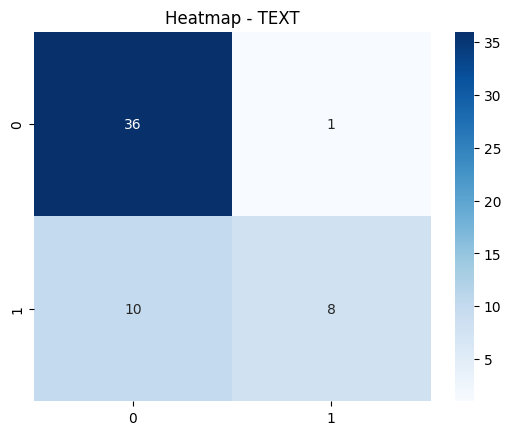

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Map string labels to integers for consistency with confusion_matrix
label_mapping = {"dementia": 0, "dementia_with_depression": 1}

y_test_numerical = y_test.map(label_mapping)

y_pred_labels = model.predict(X_test)
y_pred_numerical = pd.Series(y_pred_labels).map(label_mapping)

cm = confusion_matrix(y_test_numerical, y_pred_numerical)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Heatmap - TEXT")
plt.show()

In [17]:
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

skf = StratifiedKFold(n_splits=5)

scores = []

for train_idx, test_idx in skf.split(X_dem, y):

    X_tr, X_te = X_dem[train_idx], X_dem[test_idx]
    y_tr_str, y_te_str = y.iloc[train_idx], y.iloc[test_idx]

    # Convert string labels to numerical labels (0 and 1)
    y_tr = y_tr_str.map({"dementia": 0, "dementia_with_depression": 1})
    y_te = y_te_str.map({"dementia": 0, "dementia_with_depression": 1})

    model = Sequential([
        Dense(128, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy')

    model.fit(X_tr, y_tr, epochs=20, verbose=0)

    pred = (model.predict(X_te) > 0.3).astype(int).flatten()

    acc = np.mean(pred == y_te)
    scores.append(acc)

print("AVG (TEXT):", np.mean(scores))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
AVG (TEXT): 0.8939393939393941


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


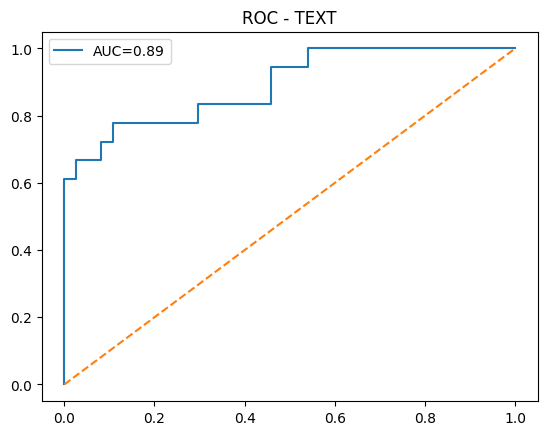

In [18]:
y_prob = model.predict(X_test)

label_mapping = {"dementia": 0, "dementia_with_depression": 1}
y_test_numerical = y_test.map(label_mapping)

fpr, tpr, _ = roc_curve(y_test_numerical, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC={roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.title("ROC - TEXT")
plt.legend()
plt.show()

In [19]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, recall_score

acc_list = []
f1_list = []
rec_list = []

In [20]:
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.models import Sequential

# Map string labels to numerical (0 and 1)
label_mapping = {
    "dementia": 0,
    "dementia_with_depression": 1
}
y_train_numerical = y_train.map(label_mapping)
y_test_numerical = y_test.map(label_mapping)


for i in range(5):

    print(f"\nRun {i+1}")

    # إعادة بناء المودل (مهم جدًا)
    model = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy')

    # تدريب
    model.fit(X_train, y_train_numerical, epochs=30, verbose=0)

    # Prediction
    y_pred = (model.predict(X_test) > 0.3).astype(int)

    # حساب المقاييس
    acc_list.append(accuracy_score(y_test_numerical, y_pred))
    f1_list.append(f1_score(y_test_numerical, y_pred, average="weighted"))
    rec_list.append(recall_score(y_test_numerical, y_pred, average="weighted"))


Run 1
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step

Run 2
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step

Run 3
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

Run 4
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step

Run 5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


In [21]:
print("\n===== RESULTS AFTER TRAINING =====")

print("Accuracy Mean:", np.mean(acc_list))
print("Accuracy Std :", np.std(acc_list))

print("F1 Mean:", np.mean(f1_list))
print("F1 Std :", np.std(f1_list))

print("Recall Mean:", np.mean(rec_list))
print("Recall Std :", np.std(rec_list))


===== RESULTS AFTER TRAINING =====
Accuracy Mean: 0.7818181818181819
Accuracy Std : 0.025712973861329008
F1 Mean: 0.7852511399097708
F1 Std : 0.02555481477618473
Recall Mean: 0.7818181818181819
Recall Std : 0.025712973861329008


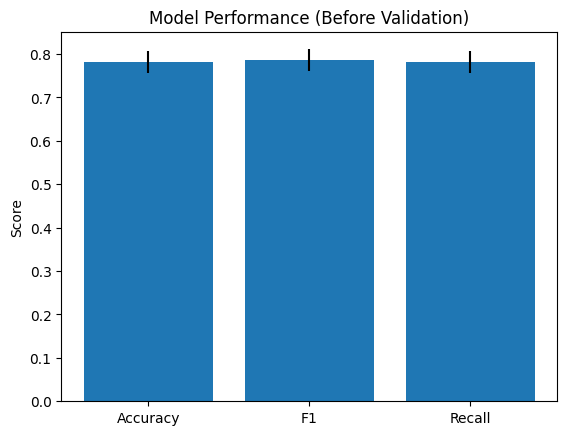

In [22]:
import matplotlib.pyplot as plt

means = [
    np.mean(acc_list),
    np.mean(f1_list),
    np.mean(rec_list)
]

stds = [
    np.std(acc_list),
    np.std(f1_list),
    np.std(rec_list)
]

labels = ["Accuracy", "F1", "Recall"]

plt.bar(labels, means, yerr=stds)
plt.title("Model Performance (Before Validation)")
plt.ylabel("Score")
plt.show()

Audio

In [23]:
import os
import numpy as np
import pandas as pd
import librosa

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, recall_score

In [24]:
dementia_audio_path = "/content/drive/MyDrive/Colab Notebooks/MICCAI_Project/raw_data/dementia/audio"
depression_audio_path = "/content/drive/MyDrive/Colab Notebooks/MICCAI_Project/raw_data/depression/audio"

In [25]:
def extract_audio_features(file_path):

    y, sr = librosa.load(file_path, sr=16000)

    f0 = librosa.yin(y, fmin=50, fmax=400)

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=10)

    return {
        "f0_mean": np.mean(f0),
        "f0_std": np.std(f0),
        "rms": np.mean(librosa.feature.rms(y=y)),
        "zcr": np.mean(librosa.feature.zero_crossing_rate(y)),
        "centroid": np.mean(librosa.feature.spectral_centroid(y=y, sr=sr)),
        "jitter": np.std(np.diff(y)),
        "shimmer": np.mean(np.abs(y)),
        **{f"mfcc_{i}": np.mean(mfcc[i]) for i in range(10)}
    }

In [26]:
def build_audio_df(path, label):

    data = []

    for f in os.listdir(path):
        if f.endswith(".wav"):

            feats = extract_audio_features(os.path.join(path,f))
            feats["id"] = f.replace(".wav","")
            feats["label"] = label

            data.append(feats)

    return pd.DataFrame(data)

In [28]:
dep_audio = build_audio_df(depression_audio_path, "depression")
dem_audio = build_audio_df(dementia_audio_path, "dementia")

In [29]:
X_dep = dep_audio.drop(["id","label"], axis=1).values
X_dem = dem_audio.drop(["id","label"], axis=1).values

scaler = StandardScaler()

X_dep_s = scaler.fit_transform(X_dep)
X_dem_s = scaler.transform(X_dem)

# clustering على الزهايمر
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_dem_s)

dem_audio["cluster"] = clusters

In [30]:
centroid_dep = X_dep_s.mean(axis=0)

cluster_scores = {}

for c in [0,1]:
    cluster_data = X_dem_s[clusters == c]
    sim = cosine_similarity(cluster_data, centroid_dep.reshape(1,-1))
    cluster_scores[c] = sim.mean()

dep_cluster = max(cluster_scores, key=cluster_scores.get)

dem_audio["new_label"] = dem_audio["cluster"].apply(
    lambda x: "dementia_with_depression" if x==dep_cluster else "dementia"
)

In [31]:
dem_audio.to_csv("audio_realistic_clustered.csv", index=False)

In [32]:
print(dem_audio[["id","new_label"]].head())
print("\nDistribution:")
print(dem_audio["new_label"].value_counts())

        id                 new_label
0    097-1                  dementia
1    120-0                  dementia
2  120-4_1  dementia_with_depression
3  120-3_1                  dementia
4    120-2                  dementia

Distribution:
new_label
dementia                    185
dementia_with_depression     88
Name: count, dtype: int64


In [33]:
X = X_dem
y = dem_audio["new_label"]

X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

model = SVC(kernel="rbf")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [34]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average="weighted"))
print("Recall:", recall_score(y_test, y_pred, average="weighted"))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9454545454545454
F1 Score: 0.9458180471879102
Recall: 0.9454545454545454
                          precision    recall  f1-score   support

                dementia       0.97      0.95      0.96        37
dementia_with_depression       0.89      0.94      0.92        18

                accuracy                           0.95        55
               macro avg       0.93      0.95      0.94        55
            weighted avg       0.95      0.95      0.95        55

[[35  2]
 [ 1 17]]


In [36]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
error_rate = 1 - acc

print("Accuracy :", acc)
print("Error Rate :", error_rate)
print("Error Rate (%) :", error_rate*100)

Accuracy : 0.9454545454545454
Error Rate : 0.054545454545454564
Error Rate (%) : 5.454545454545457


In [37]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, recall_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

acc_list = []
f1_list = []
rec_list = []

# عدد مرات التكرار
runs = 5

# Map string labels to numerical for Keras
label_mapping = {
    "dementia": 0,
    "dementia_with_depression": 1
}
y_train_numerical = y_train.map(label_mapping)
y_test_numerical = y_test.map(label_mapping)

for i in range(runs):

    print(f"\nRun {i+1} - AUDIO")

    # إعادة بناء المودل
    model = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy')

    # تدريب
    model.fit(X_train, y_train_numerical, epochs=30, verbose=0)

    # Prediction
    y_pred = (model.predict(X_test) > 0.3).astype(int)

    # Metrics
    acc_list.append(accuracy_score(y_test_numerical, y_pred))
    f1_list.append(f1_score(y_test_numerical, y_pred, average="weighted"))
    rec_list.append(recall_score(y_test_numerical, y_pred, average="weighted"))

# =========================
# النتائج
# =========================
print("\n===== AUDIO RESULTS ====")

print("Accuracy Mean:", np.mean(acc_list))
print("Accuracy Std :", np.std(acc_list))

print("F1 Mean:", np.mean(f1_list))
print("F1 Std :", np.std(f1_list))

print("Recall Mean:", np.mean(rec_list))
print("Recall Std :", np.std(rec_list))


Run 1 - AUDIO
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step

Run 2 - AUDIO
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step

Run 3 - AUDIO
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step

Run 4 - AUDIO
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step

Run 5 - AUDIO
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step

===== AUDIO RESULTS ====
Accuracy Mean: 0.9018181818181817
Accuracy Std : 0.021818181818181827
F1 Mean: 0.9043907873402489
F1 Std : 0.021004645727098037
Recall Mean: 0.9018181818181817
Recall Std : 0.021818181818181827


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


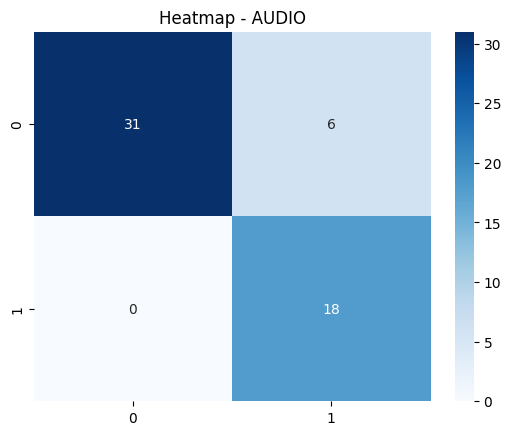

In [38]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Map string labels to integers for consistency with confusion_matrix
label_mapping = {"dementia": 0, "dementia_with_depression": 1}

y_test_numerical = y_test.map(label_mapping)

# Get predicted probabilities (which will be a 2D array)
y_pred_proba = model.predict(X_test)
# Convert predicted probabilities to class labels (0 or 1) using a threshold (e.g., 0.3 from previous cells)
# Then flatten the array to make it 1-dimensional for pd.Series and confusion_matrix
y_pred_numerical = (y_pred_proba > 0.3).astype(int).flatten()

cm = confusion_matrix(y_test_numerical, y_pred_numerical)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Heatmap - AUDIO")
plt.show()

In [39]:
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np # Ensure numpy is imported for np.mean

skf = StratifiedKFold(n_splits=5)

scores = []

for train_idx, test_idx in skf.split(X_dem, y):

    X_tr, X_te = X_dem[train_idx], X_dem[test_idx]
    y_tr_str, y_te_str = y.iloc[train_idx], y.iloc[test_idx]

    # Convert string labels to numerical labels (0 and 1)
    y_tr = y_tr_str.map({"dementia": 0, "dementia_with_depression": 1})
    y_te = y_te_str.map({"dementia": 0, "dementia_with_depression": 1})

    model = Sequential(
        [
            Dense(128, activation='relu'),
            Dense(1, activation='sigmoid')
        ]
    )

    model.compile(optimizer='adam', loss='binary_crossentropy')

    model.fit(X_tr, y_tr, epochs=20, verbose=0)

    pred = (model.predict(X_te) > 0.3).astype(int).flatten()

    acc = np.mean(pred == y_te)
    scores.append(acc)

print("AVG (Audio):", np.mean(scores))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
AVG (Audio): 0.8824915824915823


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


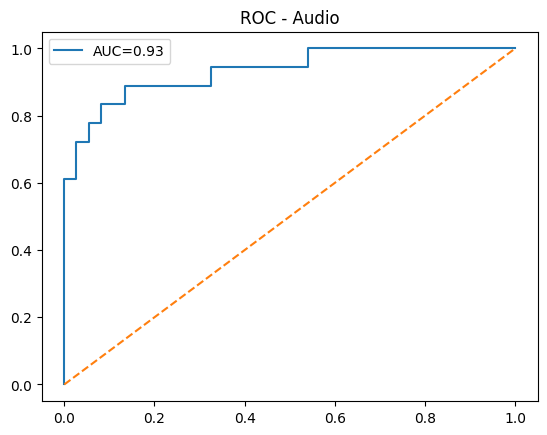

In [40]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = model.predict(X_test)

label_mapping = {"dementia": 0, "dementia_with_depression": 1}
y_test_numerical = y_test.map(label_mapping)

fpr, tpr, _ = roc_curve(y_test_numerical, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC={roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.title("ROC - Audio")
plt.legend()
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


  0%|          | 0/55 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
6607/6607 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
6607/6607 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
6607/6607 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
6607/6607 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
6607/6607 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
6607/6607 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
6607/6607 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
6607/6607 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
6607/6607 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
6607/6607 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
6607/6607 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
6607/6607 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━

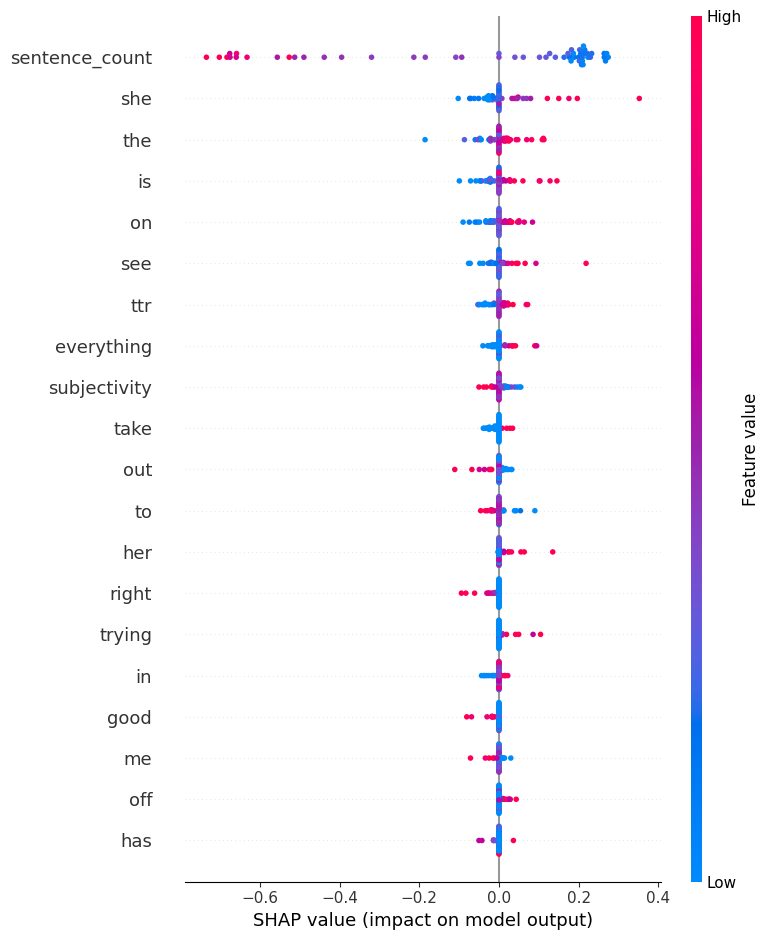

In [118]:
import shap

# The 'model' here is the Keras Sequential model from the fusion task.
# It uses 'model.predict' to get probabilities.
explainer = shap.KernelExplainer(
    model.predict, # Use model.predict for Keras Sequential model (sigmoid output)
    X_train[:100]  # X_train from the fusion task's feature selection
)

# For a single output Keras model (sigmoid), shap_values will be a single array.
# It might be (num_samples, num_features) or (num_samples, num_features, 1).
shap_values = explainer.shap_values(
    X_test[:100] # X_test from the fusion task's feature selection
)

# Ensure shap_values is 2D and use the correct feature names for the fusion model (top_features).
shap.summary_plot(
    shap_values.squeeze(), # .squeeze() handles both (N,F) and (N,F,1) cases
    X_test[:100],
    feature_names=top_features # Use the fusion model's selected feature names
)

In [120]:
print(len(audio_feature_names))
print(X_dem_audio.shape)

19
(273, 19)


In [122]:
from sklearn.model_selection import train_test_split

# Split X_dem_audio into training and testing sets
X_train_audio, X_test_audio, _, _ = train_test_split(
    X_dem_audio, dem_audio['new_label'], test_size=0.2, random_state=42, stratify=dem_audio['new_label']
)

print("X_train_audio shape:", X_train_audio.shape)
print("X_test_audio shape:", X_test_audio.shape)
print("Audio Feature Names:", audio_feature_names)

X_train_audio shape: (218, 19)
X_test_audio shape: (55, 19)
Audio Feature Names: ['rms', 'zcr', 'centroid', 'rolloff', 'jitter', 'shimmer', 'mfcc_0', 'mfcc_1', 'mfcc_2', 'mfcc_3', 'mfcc_4', 'mfcc_5', 'mfcc_6', 'mfcc_7', 'mfcc_8', 'mfcc_9', 'mfcc_10', 'mfcc_11', 'mfcc_12']


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


  0%|          | 0/55 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
6519/6519 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
6519/6519 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
6519/6519 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
6519/6519 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
6519/6519 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
6519/6519 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
6519/6519 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
6519/6519 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
6519/6519 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
6519/6519 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
6519/6519 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
6519/6519 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━

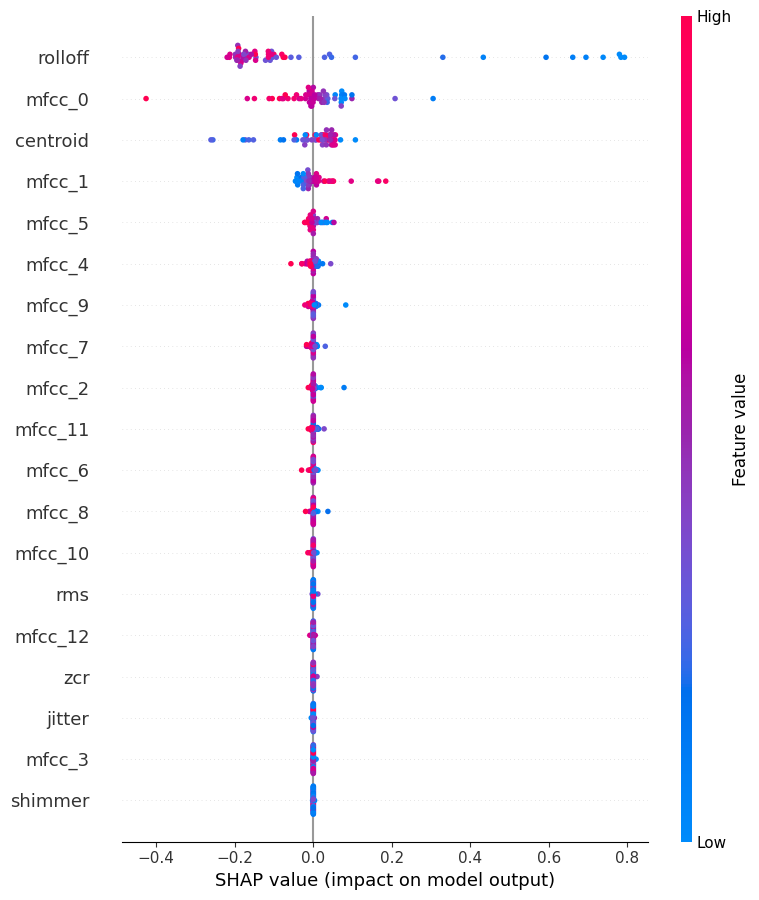

In [126]:
import shap
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

# Re-extract y_train and y_test for audio model as these were overwritten in other cells
# Use the same split as in uHQyt1GeIKBA to ensure consistency
_, _, y_train_audio_labels, y_test_audio_labels = train_test_split(
    X_dem_audio, dem_audio['new_label'], test_size=0.2, random_state=42, stratify=dem_audio['new_label']
)

# Map string labels to numerical (0 and 1) for Keras
label_mapping = {
    "dementia": 0,
    "dementia_with_depression": 1
}
y_train_audio_numerical = y_train_audio_labels.map(label_mapping)
y_test_audio_numerical = y_test_audio_labels.map(label_mapping)

# Redefine the Keras audio model with the correct input shape (19 features)
audio_model = Sequential([
    Input(shape=(X_train_audio.shape[1],)), # Input shape must match audio features
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

audio_model.compile(optimizer='adam', loss='binary_crossentropy')

# Train the audio model
audio_model.fit(X_train_audio, y_train_audio_numerical, epochs=30, verbose=0)

background = shap.sample(X_train_audio, 100)

# Use the newly trained audio_model for the explainer
explainer = shap.KernelExplainer(
    audio_model.predict,
    background
)

shap_values = explainer.shap_values(
    X_test_audio[:100]
)

# The previous context mentions that top_features should be used for feature names
# Let's ensure audio_feature_names is correctly defined here or fetched from the kernel state if available
# Based on the context, audio_feature_names was printed in uHQyt1GeIKBA and is a global variable.
# Also shap_values might be a list if multi-output, for binary classification it's often a list of one array
# If it's a list, we need to access the first element and then squeeze.
if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[0].squeeze()
else:
    shap_values_to_plot = shap_values.squeeze()

shap.summary_plot(
    shap_values_to_plot, # .squeeze() handles both (N,F) and (N,F,1) cases
    X_test_audio[:100],
    feature_names=audio_feature_names
)


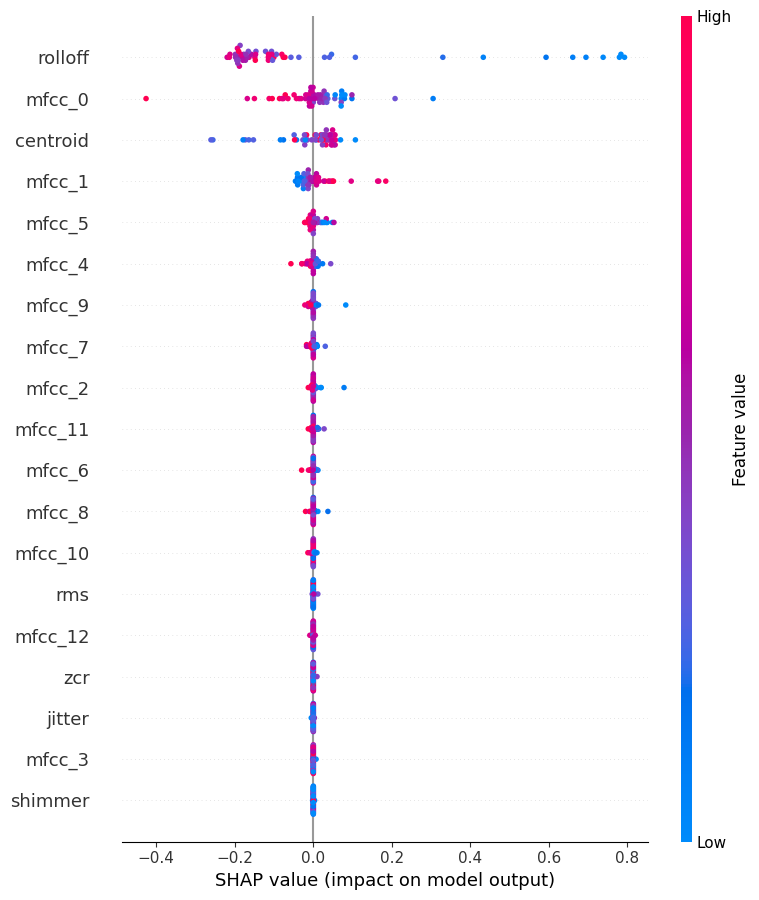

In [128]:
shap.summary_plot(
    shap_values_to_plot,
    X_test_audio[:100],
    feature_names=audio_feature_names,
    max_display=20
)

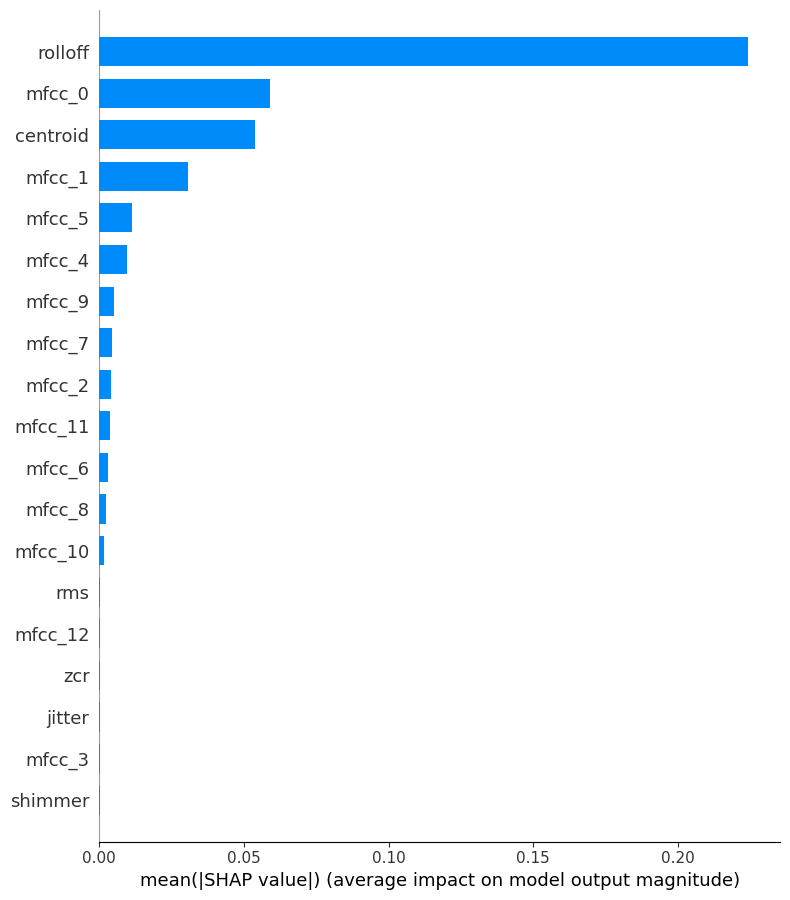

In [130]:
shap.summary_plot(
    shap_values_to_plot,
    X_test_audio[:100],
    feature_names=audio_feature_names,
    plot_type="bar",
    max_display=20
)

 ANN
طريقة مختلفة للتجربة الاخيرة


In [132]:
import os
import numpy as np
import pandas as pd
import librosa
import nltk

from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics.pairwise import cosine_similarity

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix

from sklearn.utils import resample

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

In [133]:
nltk.download('punkt')
nltk.download('punkt_tab')

def extract_text_features(text):
    tokens = nltk.word_tokenize(text.lower())
    sentences = nltk.sent_tokenize(text)

    blob = TextBlob(text)

    return {
        "word_count": len(tokens),
        "sentence_count": len(sentences),
        "ttr": len(set(tokens))/(len(tokens)+1),
        "avg_sentence_len": len(tokens)/(len(sentences)+1),
        "sentiment": blob.sentiment.polarity,
        "subjectivity": blob.sentiment.subjectivity
    }

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [134]:
def extract_audio_features(file):

    y, sr = librosa.load(file, sr=16000)

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

    return {
        "rms": np.mean(librosa.feature.rms(y=y)),
        "zcr": np.mean(librosa.feature.zero_crossing_rate(y)),
        "centroid": np.mean(librosa.feature.spectral_centroid(y=y, sr=sr)),
        "rolloff": np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr)),
        "jitter": np.std(np.diff(y)),
        "shimmer": np.mean(np.abs(y)),
        **{f"mfcc_{i}": np.mean(mfcc[i]) for i in range(13)}
    }

In [135]:
def load_text(path):
    texts = []
    feats = []
    ids = []

    for f in os.listdir(path):
        if f.endswith(".txt"):
            text = open(os.path.join(path,f)).read()
            texts.append(text)
            feats.append(extract_text_features(text))
            ids.append(f.replace(".txt",""))

    return texts, pd.DataFrame(feats), ids


def load_audio(path):
    feats = []
    ids = []

    for f in os.listdir(path):
        if f.endswith(".wav"):
            feats.append(extract_audio_features(os.path.join(path,f)))
            ids.append(f.replace(".wav",""))

    return pd.DataFrame(feats), ids

In [136]:
dep_text_path = "/content/drive/MyDrive/Colab Notebooks/MICCAI_Project/raw_data/depression/transcripts"
dep_audio_path = "/content/drive/MyDrive/Colab Notebooks/MICCAI_Project/raw_data/depression/audio/"

dem_text_path = "/content/drive/MyDrive/Colab Notebooks/MICCAI_Project/raw_data/dementia/generated_transcripts/dementia/"
dem_audio_path = "/content/drive/MyDrive/Colab Notebooks/MICCAI_Project/raw_data/dementia/audio/"

In [137]:
dep_texts, dep_text_df, dep_ids = load_text(dep_text_path)
dem_texts, dem_text_df, dem_ids = load_text(dem_text_path)

dep_audio_df, _ = load_audio(dep_audio_path)
dem_audio_df, _ = load_audio(dem_audio_path)

In [138]:
vectorizer = TfidfVectorizer(max_features=200)

X_dep_tfidf = vectorizer.fit_transform(dep_texts).toarray()
X_dem_tfidf = vectorizer.transform(dem_texts).toarray()

In [139]:
X_dep_text = np.hstack([X_dep_tfidf, dep_text_df.values])
X_dem_text = np.hstack([X_dem_tfidf, dem_text_df.values])

X_dep_audio = dep_audio_df.values
X_dem_audio = dem_audio_df.values

X_dep = np.hstack([X_dep_text, X_dep_audio])
X_dem = np.hstack([X_dem_text, X_dem_audio])

In [140]:
scaler = StandardScaler()

X_dep_s = scaler.fit_transform(X_dep)
X_dem_s = scaler.transform(X_dem)

In [141]:
gmm = GaussianMixture(n_components=2, random_state=42)
clusters = gmm.fit_predict(X_dem_s)

dep_centroid = X_dep_s.mean(axis=0)

scores = {}
for c in [0,1]:
    sim = cosine_similarity(X_dem_s[clusters==c], dep_centroid.reshape(1,-1))
    scores[c] = sim.mean()

dep_cluster = max(scores, key=scores.get)

y = np.array([1 if c==dep_cluster else 0 for c in clusters])

In [142]:
X_train, X_test, y_train, y_test = train_test_split(
    X_dem_s, y, test_size=0.2, stratify=y, random_state=42
)

In [143]:
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dropout(0.4),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')
])

In [144]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.4713 - loss: 2.8622 - val_accuracy: 0.3409 - val_loss: 1.2266
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4828 - loss: 2.4262 - val_accuracy: 0.7500 - val_loss: 0.4825
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5977 - loss: 1.6852 - val_accuracy: 0.7500 - val_loss: 0.6877
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6724 - loss: 1.3956 - val_accuracy: 0.7955 - val_loss: 0.4788
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7184 - loss: 1.2070 - val_accuracy: 0.9318 - val_loss: 0.3124
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7644 - loss: 0.8584 - val_accuracy: 0.8182 - val_loss: 0.3613
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6494 - loss: 0.8175 - val_accuracy: 0.8864 - val_loss: 0.2953
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8046 - loss: 0.5493 - val_accuracy: 0.9091 - val_loss: 0.2603


In [145]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9195 - loss: 0.1797 - val_accuracy: 1.0000 - val_loss: 0.0603
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9310 - loss: 0.1807 - val_accuracy: 1.0000 - val_loss: 0.0577
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9425 - loss: 0.1608 - val_accuracy: 0.9773 - val_loss: 0.0622
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9195 - loss: 0.1087 - val_accuracy: 0.9318 - val_loss: 0.0864
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9540 - loss: 0.1064 - val_accuracy: 0.9773 - val_loss: 0.0740
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9540 - loss: 0.1293 - val_accuracy: 0.9773 - val_loss: 0.0504
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9310 - loss: 0.1773 - val_accuracy: 0.9773 - val_loss: 0.0475
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9655 - loss: 0.1365 - val_accuracy: 0.9773 - val_loss: 0.0401


In [146]:
y_prob = model.predict(X_test)

# تحسين Recall
y_pred = (y_prob > 0.3).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
Accuracy: 0.9090909090909091
F1: 0.935064935064935
Recall: 0.972972972972973

Confusion Matrix:
[[14  4]
 [ 1 36]]


In [147]:
from sklearn.metrics import accuracy_score
import numpy as np

y_prob = model.predict(X_test)

y_pred = (y_prob > 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
error_rate = 1 - acc

print("Accuracy :", acc)
print("Error Rate :", error_rate)
print("Error Rate (%) :", error_rate*100)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Accuracy : 0.9090909090909091
Error Rate : 0.09090909090909094
Error Rate (%) : 9.090909090909093


/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_126
Received: inputs=['Tensor(shape=(100, 225))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_126
Received: inputs=['Tensor(shape=(200, 225))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_126
Received: inputs=['Tensor(shape=(55, 225))']
  wa

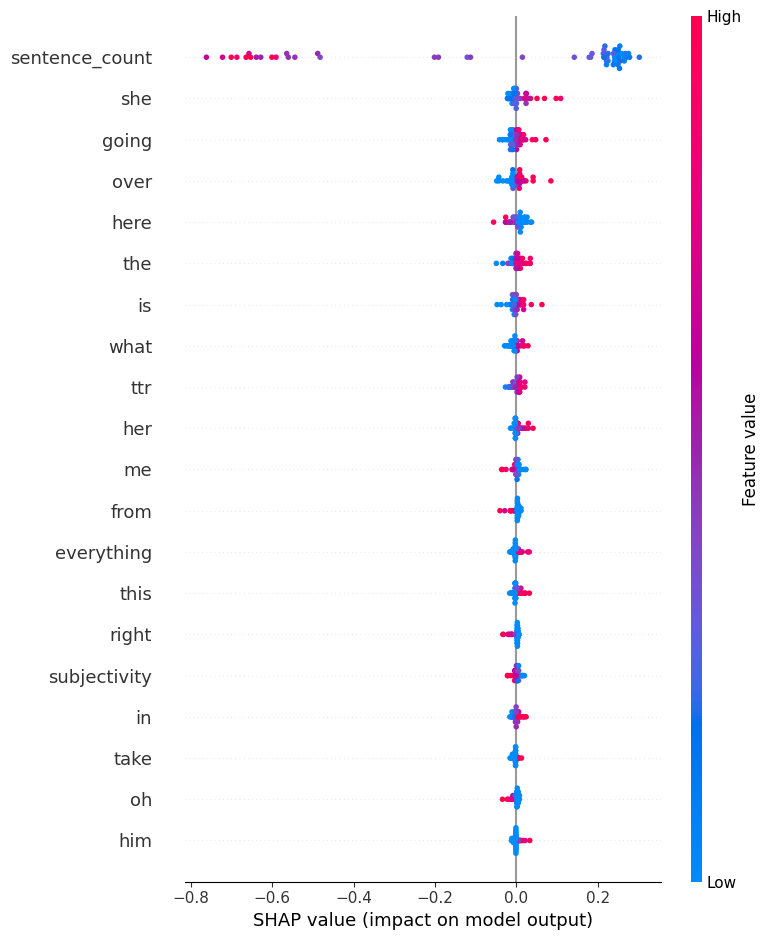

In [150]:
explainer = shap.DeepExplainer(
    model,
    X_fusion_train[:100]
)

shap_values = explainer.shap_values(
    X_fusion_test[:100]
)

shap.summary_plot(
    shap_values.squeeze(),
    X_fusion_test[:100],
    feature_names=feature_names
)

In [151]:
print(len(audio_feature_names))
print(X_test_audio.shape)

19
(55, 19)


In [153]:
print(X_dem_audio.shape)
print(len(audio_feature_names))
print(audio_feature_names[:10])

(273, 19)
19
['rms', 'zcr', 'centroid', 'rolloff', 'jitter', 'shimmer', 'mfcc_0', 'mfcc_1', 'mfcc_2', 'mfcc_3']


In [155]:
print(feature_names)
print(len(feature_names))

['able', 'about', 'actually', 'ago', 'all', 'also', 'always', 'am', 'an', 'and', 'any', 'anything', 'are', 'around', 'as', 'at', 'away', 'back', 'bad', 'be', 'because', 'been', 'being', 'best', 'better', 'bit', 'but', 'by', 'can', 'cause', 'close', 'could', 'day', 'did', 'didn', 'different', 'do', 'doing', 'don', 'done', 'down', 'easy', 'eh', 'even', 'everything', 'family', 'feel', 'feeling', 'felt', 'for', 'friend', 'friends', 'from', 'fun', 'get', 'getting', 'go', 'going', 'gonna', 'good', 'got', 'great', 'guess', 'had', 'happy', 'hard', 'has', 'have', 'haven', 'having', 'he', 'help', 'her', 'here', 'him', 'hmm', 'how', 'if', 'in', 'into', 'is', 'it', 'job', 'just', 'kind', 'kinda', 'know', 'last', 'laughter', 'let', 'life', 'like', 'little', 'll', 'long', 'lot', 'love', 'made', 'make', 'maybe', 'me', 'mean', 'mhm', 'mm', 'more', 'most', 'much', 'my', 'myself', 'never', 'new', 'nice', 'no', 'not', 'now', 'of', 'off', 'oh', 'okay', 'on', 'one', 'or', 'other', 'out', 'over', 'own', 'pe

In [159]:
print(importance_df.head(30))

           Feature  Importance
0   sentence_count    0.298410
2              she    0.052726
6              the    0.044065
1               is    0.036569
18              on    0.034154
5              ttr    0.031358
3              see    0.026990
4       everything    0.022036
27             out    0.021227
26             her    0.020738
13    subjectivity    0.019330
23            take    0.019116
25              to    0.016864
14           right    0.016302
10              in    0.015680
21              he    0.014252
28            good    0.013801
17          trying    0.013043
9             here    0.012588
22             off    0.011909
16              me    0.011617
19             can    0.011287
15         getting    0.010489
11              up    0.009738
29            what    0.008806
7              has    0.008211
12          mfcc_5    0.007828
8             okay    0.007676
32             too    0.006172
31         mfcc_10    0.004970


In [161]:
audio_cols = [
    'rms','zcr','centroid','rolloff',
    'jitter','shimmer',
    'mfcc_0','mfcc_1','mfcc_2',
    'mfcc_3','mfcc_4','mfcc_5',
    'mfcc_6','mfcc_7','mfcc_8',
    'mfcc_9','mfcc_10','mfcc_11',
    'mfcc_12'
]

audio_importance = importance_df[
    importance_df.Feature.isin(audio_cols)
]

audio_importance = audio_importance.sort_values(
    by="Importance",
    ascending=False
)

print(audio_importance)

     Feature  Importance
12    mfcc_5    0.007828
31   mfcc_10    0.004970
30  centroid    0.004017


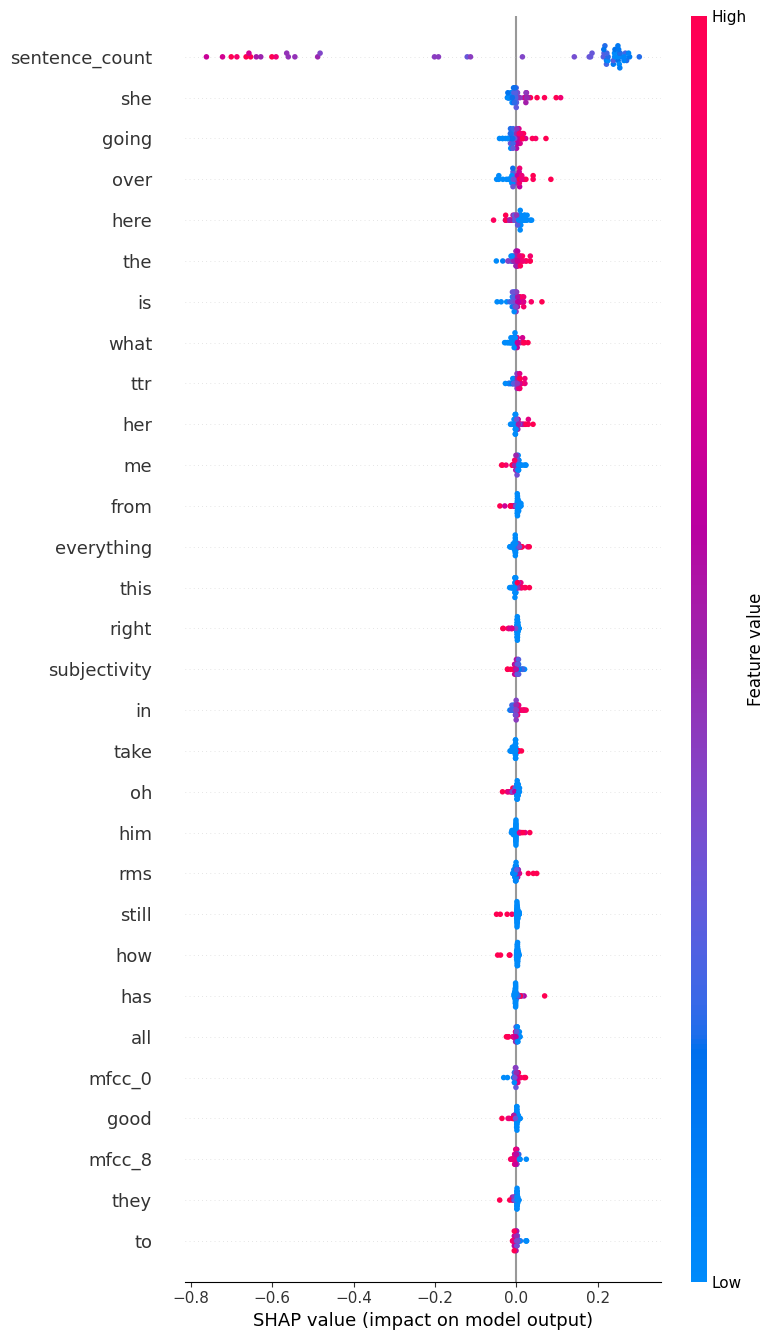

In [165]:
shap.summary_plot(
    shap_values.squeeze(),
    X_fusion_test[:100],
    feature_names=feature_names,
    max_display=30
)

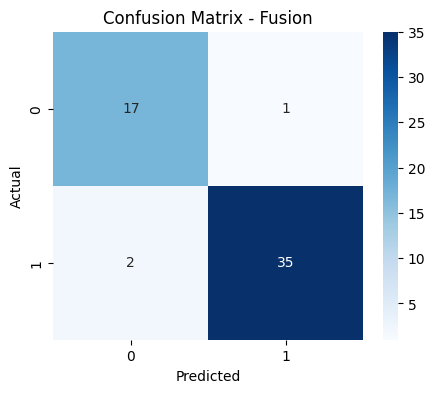

In [57]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Fusion")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

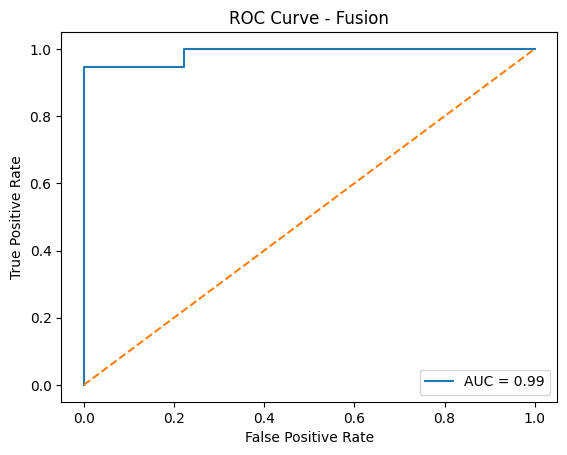

In [58]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Fusion")

plt.legend()
plt.show()

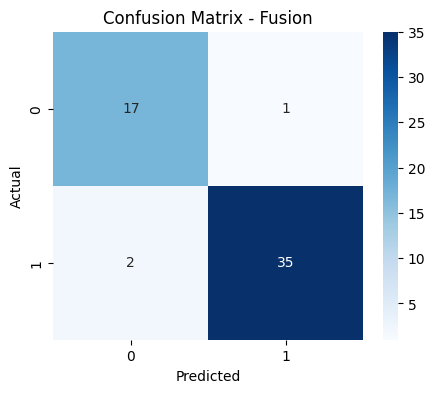

In [59]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Fusion")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [60]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, f1_score, recall_score
from sklearn.metrics import confusion_matrix, roc_curve, auc

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [61]:
acc_list = []
f1_list = []
rec_list = []
error_list = []

runs = 5

In [62]:
X_fusion = X_dem_s
y_fusion = y

X_fusion_train, X_fusion_test, y_fusion_train, y_fusion_test = train_test_split(
    X_fusion, y_fusion, test_size=0.2, stratify=y_fusion, random_state=42
)

# Map string labels to numerical for Keras - NOT NEEDED AS Y IS ALREADY NUMERICAL
# label_mapping = {
#     "dementia": 0,
#     "dementia_with_depression": 1
# }
# y_fusion_train = pd.Series(y_fusion_train).map(label_mapping).values
# y_fusion_test = pd.Series(y_fusion_test).map(label_mapping).values

for i in range(runs):

    print(f"\nRun {i+1} - FUSION")

    model = Sequential([
        Input(shape=(X_fusion_train.shape[1],)),
        Dense(256, activation='relu'),
        Dropout(0.5),

        Dense(128, activation='relu'),
        Dropout(0.4),

        Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy')

    model.fit(X_fusion_train, y_fusion_train, epochs=30, verbose=0)

    # Prediction
    y_prob = model.predict(X_fusion_test)
    y_pred = (y_prob > 0.3).astype(int)

    # Metrics
    acc = accuracy_score(y_fusion_test, y_pred)
    f1  = f1_score(y_fusion_test, y_pred, average="weighted")
    rec = recall_score(y_fusion_test, y_pred, average="weighted")

    error = 1 - acc

    acc_list.append(acc)
    f1_list.append(f1)
    rec_list.append(rec)
    error_list.append(error)


Run 1 - FUSION
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

Run 2 - FUSION
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step

Run 3 - FUSION
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step

Run 4 - FUSION
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step

Run 5 - FUSION
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


In [63]:
print("\n===== FUSION RESULTS =====")

print("Accuracy Mean:", np.mean(acc_list))
print("Accuracy Std :", np.std(acc_list))

print("F1 Mean:", np.mean(f1_list))
print("F1 Std :", np.std(f1_list))

print("Recall Mean:", np.mean(rec_list))
print("Recall Std :", np.std(rec_list))

print("Error Rate Mean:", np.mean(error_list))
print("Error Rate Std :", np.std(error_list))


===== FUSION RESULTS =====
Accuracy Mean: 0.9490909090909092
Accuracy Std : 0.021203461435801096
F1 Mean: 0.9481412652303189
F1 Std : 0.0219766258751978
Recall Mean: 0.9490909090909092
Recall Std : 0.021203461435801096
Error Rate Mean: 0.050909090909090925
Error Rate Std : 0.0212034614358011


In [64]:
import pandas as pd

# Define feature names based on how X_fusion was constructed
# X_fusion was X_dem_s, which came from scaling X_dem
# X_dem = np.hstack([X_dem_text, X_dem_audio])
# X_dem_text = np.hstack([X_dem_tfidf, dem_text_df.values])
# X_dem_tfidf from vectorizer

tfidf_feature_names = vectorizer.get_feature_names_out().tolist()
manual_text_feature_names = dem_text_df.columns.tolist()
audio_feature_names = dem_audio_df.columns.tolist()

feature_names = tfidf_feature_names + manual_text_feature_names + audio_feature_names

df = pd.DataFrame(X_fusion, columns=feature_names)

In [65]:
corr_matrix = df.corr()

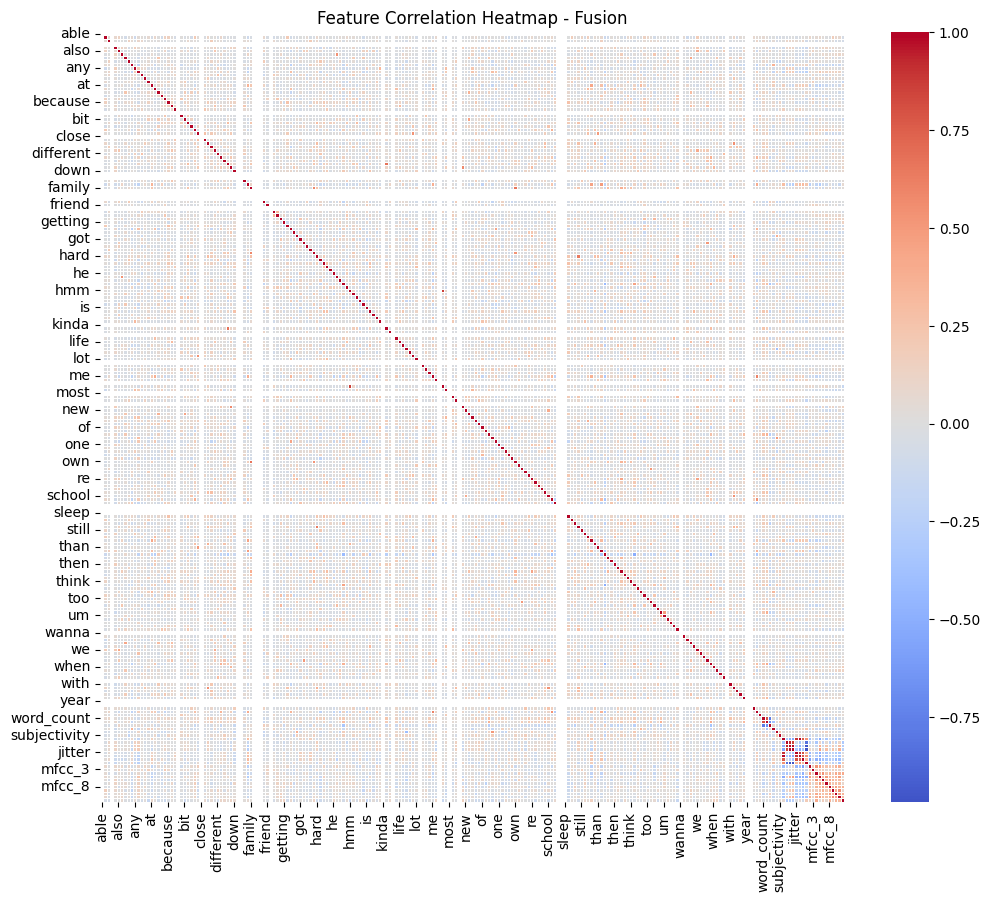

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap - Fusion")
plt.show()

<Axes: >

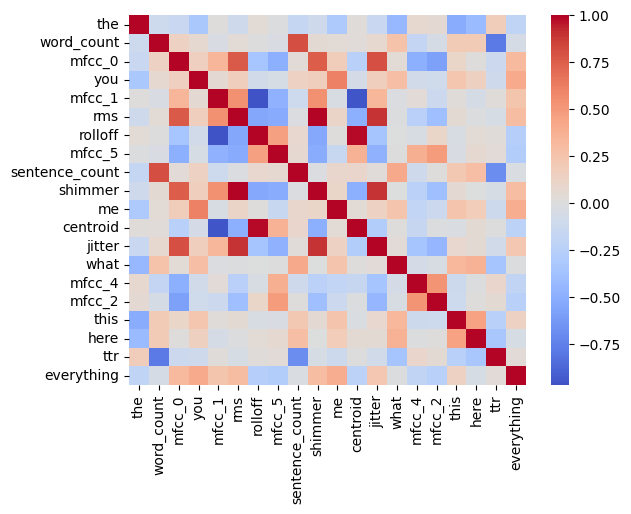

In [67]:
top_features = df.corr().abs().mean().sort_values(ascending=False).head(20).index
df_small = df[top_features]

sns.heatmap(df_small.corr(), cmap="coolwarm", center=0)

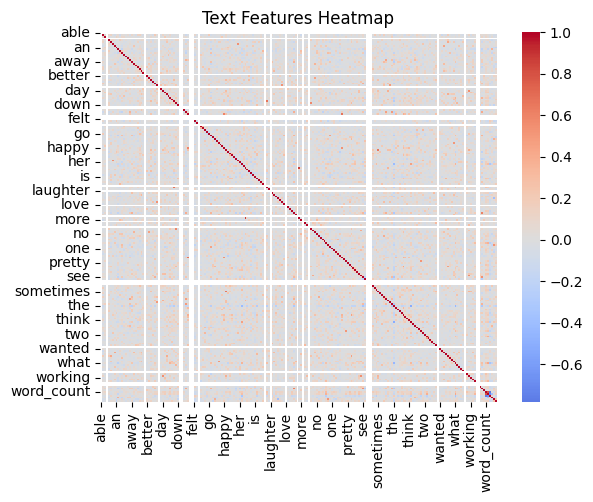

In [68]:
X_text = X_dem_text
text_feature_names = tfidf_feature_names + manual_text_feature_names

df_text = pd.DataFrame(X_text, columns=text_feature_names)

sns.heatmap(df_text.corr(), cmap="coolwarm", center=0)
plt.title("Text Features Heatmap")
plt.show()

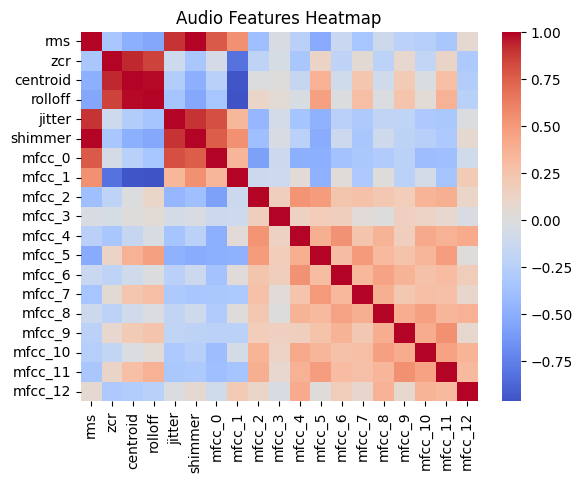

In [69]:
df_audio = pd.DataFrame(X_dem_audio, columns=audio_feature_names)

sns.heatmap(df_audio.corr(), cmap="coolwarm", center=0)
plt.title("Audio Features Heatmap")
plt.show()

/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_106
Received: inputs=['Tensor(shape=(100, 225))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_106
Received: inputs=['Tensor(shape=(200, 225))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_106
Received: inputs=['Tensor(shape=(55, 225))']
  wa

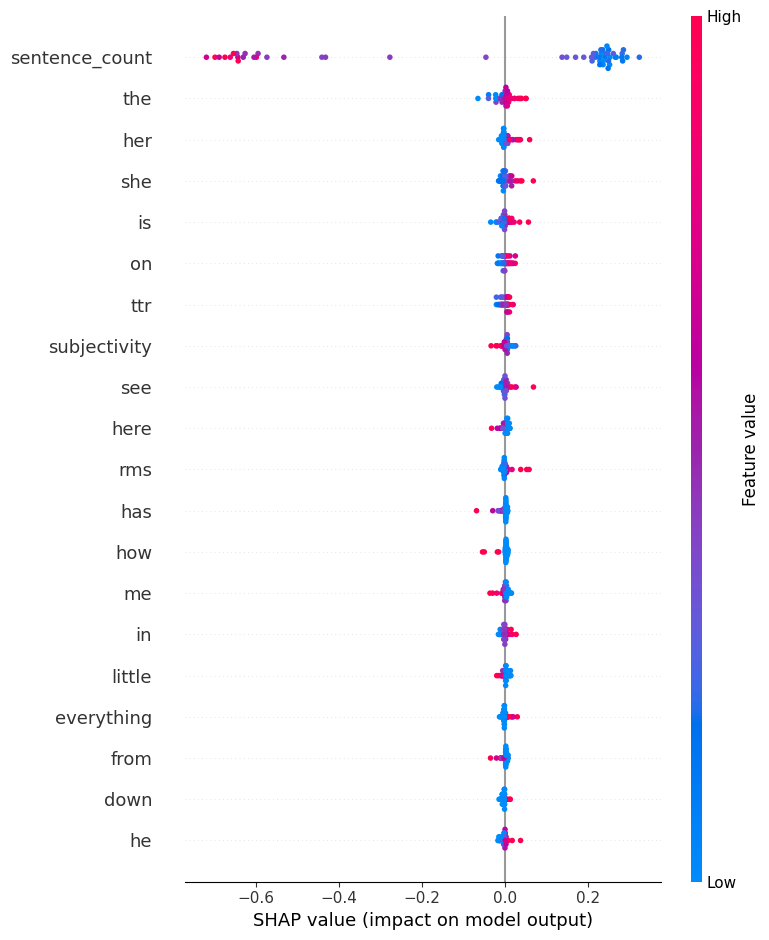

In [72]:
import shap

explainer = shap.DeepExplainer(
    model,
    X_train[:100]
)

shap_values = explainer.shap_values(
    X_test[:100]
)

shap.summary_plot(
    shap_values.squeeze(), # Fix: Remove the singleton dimension
    X_test[:100],
    feature_names=feature_names
)

مرحلة اختيار افضل السمات وتدريب المودل

In [73]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(256, activation='relu', input_shape=(X_fusion.shape[1],)),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy')

model.fit(X_fusion, y, epochs=20, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [74]:
import shap

# عينة صغيرة لتسريع الحساب
X_sample = X_fusion[:277]

explainer = shap.DeepExplainer(model, X_sample)
shap_values = explainer.shap_values(X_sample)

/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_112
Received: inputs=['Tensor(shape=(273, 225))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_112
Received: inputs=['Tensor(shape=(546, 225))']
  warnings.warn(msg)


In [75]:
import numpy as np
import pandas as pd

# متوسط القيمة المطلقة لـ SHAP values للفئة الأولى (أو الثانية حسب اختيارك) مع التأكد من أنها 1D
# shap_values from DeepExplainer with a single output model returns a 3D array of shape (num_samples, num_features, 1).
# To get the mean absolute SHAP value for each feature, we average across samples (axis 0) and the singleton output dimension (axis 2).
shap_importance = np.abs(shap_values).mean(axis=(0, 2))

feature_importance = pd.Series(shap_importance, index=feature_names)

# ترتيب
feature_importance = feature_importance.sort_values(ascending=False)

print(feature_importance.head(20))

sentence_count    0.372440
is                0.013822
she               0.013361
see               0.012715
everything        0.011366
ttr               0.010233
the               0.008074
has               0.007092
okay              0.006895
here              0.006603
in                0.006062
up                0.006026
mfcc_5            0.005640
subjectivity      0.005639
right             0.005536
getting           0.005276
me                0.004856
trying            0.004662
on                0.004654
can               0.004636
dtype: float64


In [76]:
top_k = 20
top_features = feature_importance.head(top_k).index

X_selected = pd.DataFrame(X_fusion, columns=feature_names)[top_features].values

In [77]:
threshold = feature_importance.mean()

top_features = feature_importance[feature_importance > threshold].index

X_selected = pd.DataFrame(X_fusion, columns=feature_names)[top_features].values

In [78]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, stratify=y, random_state=42
)

model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy')

model.fit(X_train, y_train, epochs=30, verbose=0)

# تقييم
from sklearn.metrics import accuracy_score, f1_score, recall_score

y_pred = (model.predict(X_test) > 0.3).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred, average="weighted"))
print("Recall:", recall_score(y_test, y_pred, average="weighted"))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Accuracy: 0.9454545454545454
F1: 0.9440377804014167
Recall: 0.9454545454545454


/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_117
Received: inputs=['Tensor(shape=(100, 33))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_117
Received: inputs=['Tensor(shape=(200, 33))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_117
Received: inputs=['Tensor(shape=(55, 33))']
  warni

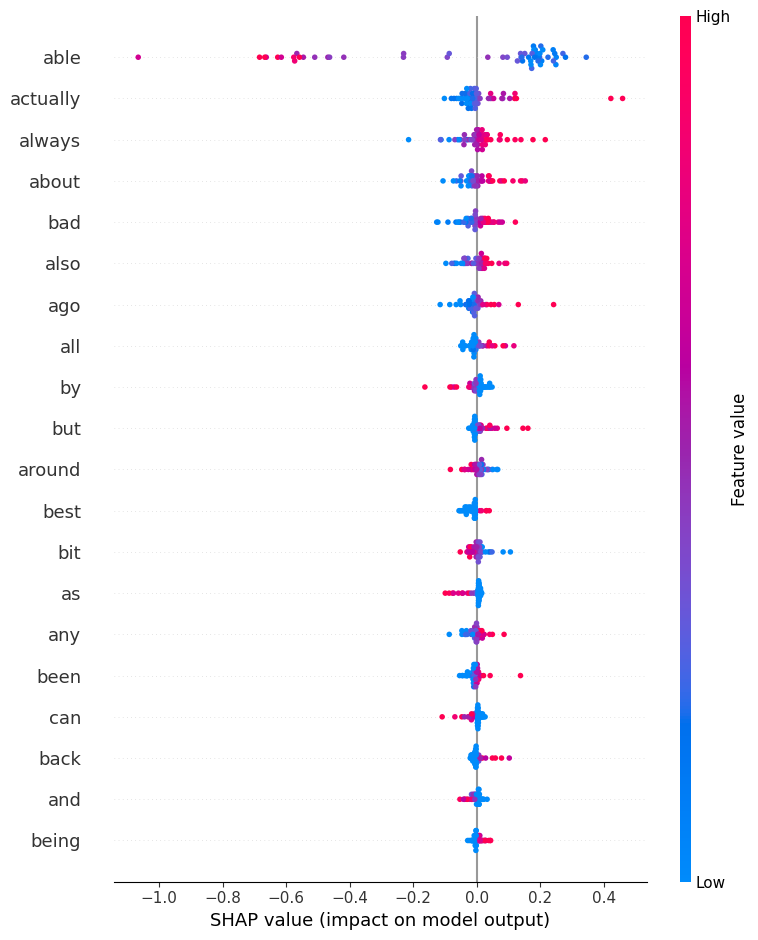

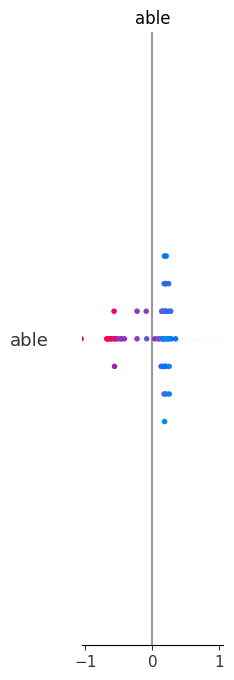

In [87]:
import shap

explainer = shap.DeepExplainer(
    model,
    X_train[:100]
)

shap_values = explainer.shap_values(
    X_test[:100]
)

shap.summary_plot(
    shap_values.squeeze(), # Applying .squeeze() to remove singleton dimension from the entire array
    X_test[:100],
    feature_names=feature_names
)
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_names,
    plot_type="dot"
)

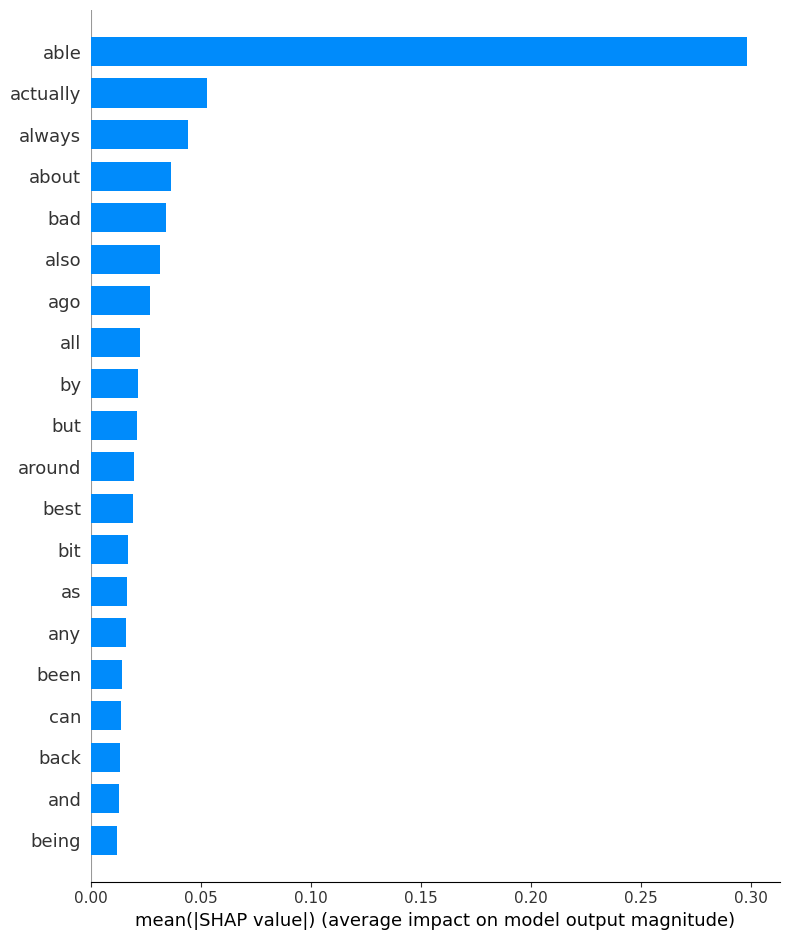

In [94]:
shap.summary_plot(
    shap_values.squeeze(),
    X_test[:100],
    feature_names=feature_names,
    plot_type="bar",
    max_display=20
)

In [102]:
import numpy as np
import pandas as pd

importance = np.abs(shap_values).mean(axis=(0, 2))

importance_df = pd.DataFrame({
    "Feature": top_features,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df.head(20))

           Feature  Importance
0   sentence_count    0.298410
2              she    0.052726
6              the    0.044065
1               is    0.036569
18              on    0.034154
5              ttr    0.031358
3              see    0.026990
4       everything    0.022036
27             out    0.021227
26             her    0.020738
13    subjectivity    0.019330
23            take    0.019116
25              to    0.016864
14           right    0.016302
10              in    0.015680
21              he    0.014252
28            good    0.013801
17          trying    0.013043
9             here    0.012588
22             off    0.011909


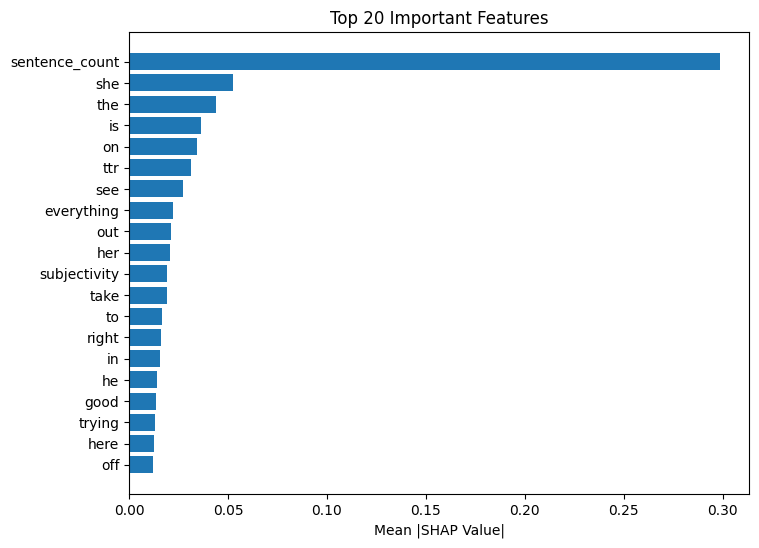

In [103]:
top20 = importance_df.head(20)

plt.figure(figsize=(8,6))
plt.barh(
    top20["Feature"],
    top20["Importance"]
)
plt.gca().invert_yaxis()
plt.xlabel("Mean |SHAP Value|")
plt.title("Top 20 Important Features")
plt.show()

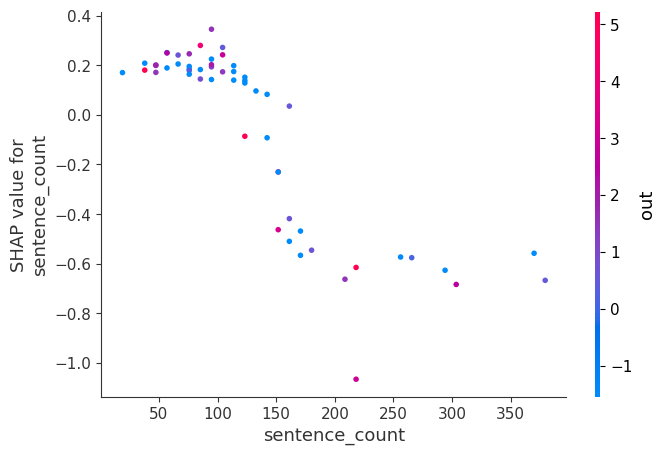

In [105]:
shap.dependence_plot(
    "sentence_count",
    shap_values.squeeze(), # Pass all shap_values for all samples
    pd.DataFrame(X_test[:100], columns=top_features), # Ensure X has column names for plotting
    feature_names=top_features
)

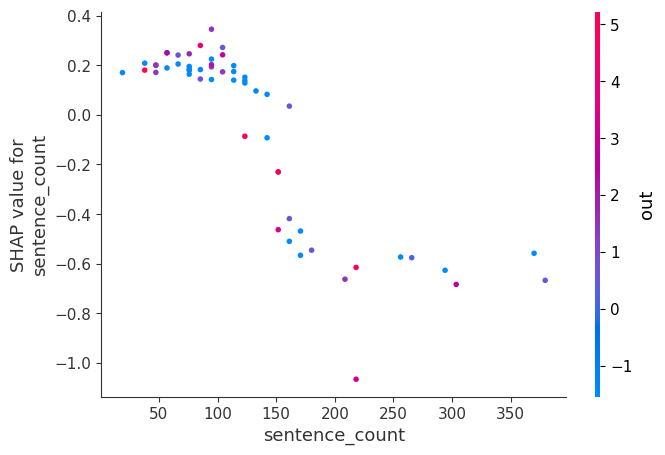

In [108]:
shap.dependence_plot(
    "sentence_count",
    shap_values.squeeze(),
    pd.DataFrame(X_test[:100], columns=top_features),
    feature_names=top_features
)

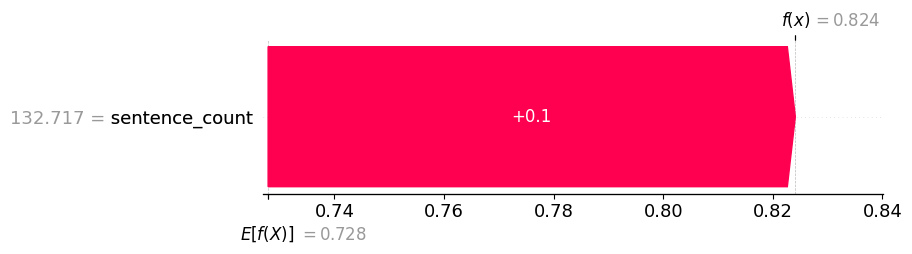

In [112]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0][0],
        base_values=explainer.expected_value[0].numpy().item(),
        data=X_test[0],
        feature_names=top_features
    )
)

In [ ]:
scores = []

for k in range(2,6):

    gmm = GaussianMixture(n_components=k, random_state=42)
    labels = gmm.fit_predict(X_dem_s)

    score = silhouette_score(X_dem_s, labels)
    scores.append(score)

    print(f"k={k} → Silhouette={score}")

k=2 → Silhouette=0.48709458315431986
k=3 → Silhouette=0.48171910955640895
k=4 → Silhouette=0.42914711940378264
k=5 → Silhouette=0.3050538336192604


In [ ]:
best_k = np.argmax(scores) + 2
print("Best k:", best_k)

gmm = GaussianMixture(n_components=best_k, random_state=42)
clusters = gmm.fit_predict(X_dem_s)

Best k: 2
